In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix

In [3]:
resp_sofa = [
    'sofa_resp_day1',
    'sofa_resp_day2',
    'sofa_resp_day3'
]

def preprocess_design_matrix(design_matrix):

    design_matrix = design_matrix[design_matrix['sofa_cns_baseline'] == 0]


    # design_matrix['sofa_resp_diff2'] = design_matrix['sofa_resp_day2'] - design_matrix['sofa_resp_baseline']
    # design_matrix['sofa_resp_diff3'] = design_matrix['sofa_resp_day3'] - design_matrix['sofa_resp_baseline']
    # design_matrix['sofa_resp_diff1'] = design_matrix['sofa_resp_day1'] - design_matrix['sofa_resp_baseline']

    # design_matrix['Resp Rate'] = np.max(
    #     design_matrix[
    #         [
    #             'sofa_resp_day1',
    #             'sofa_resp_day2',
    #             'sofa_resp_day3'
    #         ]
    #     ],
    #     axis=1
    # )
    #
    # design_matrix = design_matrix[
    #     (design_matrix['max_resp_diff'] == 0.0) |
    #     (design_matrix['max_resp_diff'] > 2.0)
    # ].copy()

    design_matrix['group'] = np.where(
        design_matrix['CNS Rate'] > design_matrix['CNS Rate'].mean(), 2, 1
    )

    design_matrix['sample'] = design_matrix['injection']

    return design_matrix

In [4]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()
    
    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix     


# Model Training

In [6]:
ms_data = pd.read_csv(
    "../0_data/proteins_train_filtered.tsv"
    , sep="\t"
)

In [7]:
design_matrix_otrain = pd.read_csv(
    "organ_dysfunction_design_matrix.tsv",
    sep="\t"
)

In [8]:
design_matrix_train = preprocess_design_matrix(design_matrix_otrain.copy())

In [9]:
design_matrix_train['group'].value_counts()

group
2    342
1    336
Name: count, dtype: int64

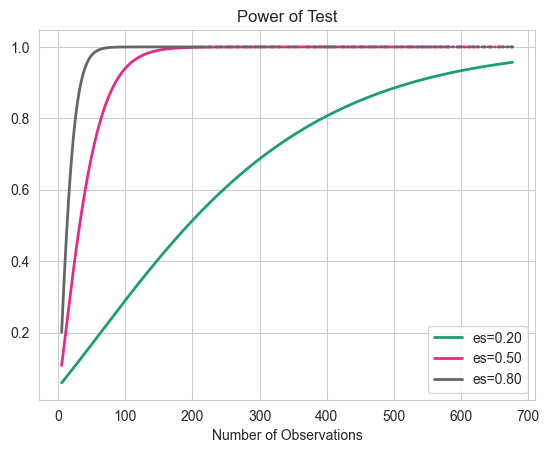

In [10]:
from statsmodels.stats.power import TTestIndPower
import matplotlib.pyplot as plt

# parameters for power analysis
effect_sizes = np.array([0.2, 0.5, 0.8])
sample_sizes = np.array(range(5, design_matrix_train.shape[0]))


analysis = TTestIndPower()

analysis.plot_power(dep_var='nobs', nobs=sample_sizes, effect_size=effect_sizes)
plt.show()

In [11]:
quant_matrix_train = preprocess_data(ms_data, design_matrix=design_matrix_train)

In [12]:
quant_matrix_train = quant_matrix_train.compare(
    method="linregress",
    comparisons=(2,1),
    min_samples_per_group=2,
    level="protein",
    multiple_testing_correction_method="fdr_tsbh"
)

In [13]:
#quant_matrix_train.write("de_results/resp_de_proteins.tsv")

In [14]:
quant_matrix_de = quant_matrix_train.to_df()

<Axes: xlabel='Log2FoldChange2-1', ylabel='-Log10CorrectedPValue2-1'>

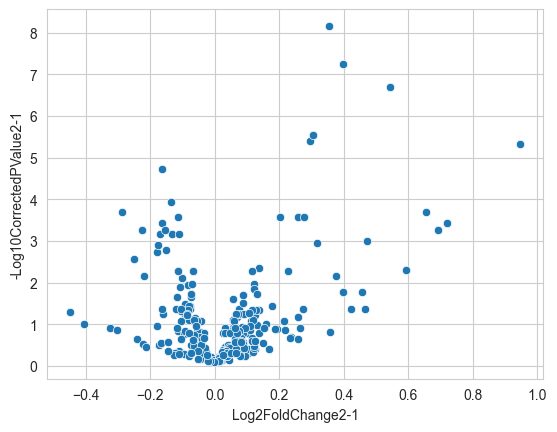

In [15]:
sns.scatterplot(
    data=quant_matrix_de,
    x="Log2FoldChange2-1",
    y="-Log10CorrectedPValue2-1"
)

In [16]:
qm_filtered = (
    
    QuantMatrix(
        quantification_file=quant_matrix_de,
        design_matrix_file=design_matrix_train
    )
    
)

In [17]:
training_data, y = qm_filtered.to_ml(feature_column="ProteinLabel")

In [18]:
protein_columns = training_data.columns.to_list()

In [19]:
len(protein_columns)

287

In [20]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.impute import SimpleImputer

X = training_data.copy()

protein_scaler = StandardScaler()

X[protein_columns] = protein_scaler.fit_transform(X[protein_columns])

X = X.copy()

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier


protein_clf = LogisticRegression(
    random_state=42,
    #penalty="l1",
    class_weight="balanced",
    #C=0.1,
    #solver="liblinear",
    max_iter=1000
)

# protein_clf = BaggingClassifier(
#     estimator=protein_clf
# )

In [22]:
# from cleanlab.filter import find_label_issues
# from sklearn.model_selection import cross_val_predict
#
# pred_probs = cross_val_predict(protein_clf, X, y.values.ravel(), cv=3, method="predict_proba")
#
# label_issues = find_label_issues(
#     labels=y.values.ravel(),
#     pred_probs=pred_probs,
#     return_indices_ranked_by='self_confidence',  # Ranks by likelihood of being mislabeled
# )

In [23]:
# label_issues

In [24]:
# mask = np.ones(len(y.values.ravel()), dtype=bool)
#
# mask[label_issues] = False

In [25]:
# mask.shape

In [26]:
# X = X.iloc[mask, :].copy()
# y = y.iloc[mask, :].copy()

In [27]:
y['label'].value_counts()

label
1    342
0    336
Name: count, dtype: int64

In [28]:
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight


class_weight = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y.values.ravel()),
    y=y.values.ravel()
)

class_weight = dict(zip(np.unique(y.values.ravel()), class_weight))

class_weight

{0: 1.0089285714285714, 1: 0.9912280701754386}

In [29]:
sample_weight = compute_sample_weight(
    class_weight=class_weight,
    y=y.values.ravel()
)

In [30]:
from mrmr import mrmr_classif
selected_proteins = mrmr_classif(X=X[protein_columns], y=y.values.ravel(), K=50)

100%|██████████| 50/50 [00:00<00:00, 62.96it/s]


In [31]:
selected_proteins

['CYTC_HUMAN',
 'KLKB1_HUMAN',
 'TENX_HUMAN',
 'LIRB1_HUMAN',
 'PSPB_HUMAN',
 'CFAB_HUMAN',
 'RS27A_HUMAN',
 'CMGA_HUMAN',
 'IBP2_HUMAN',
 'LCAT_HUMAN',
 'B2MG_HUMAN',
 'COIA1_HUMAN',
 'TETN_HUMAN',
 'LYSC_HUMAN',
 'PLMN_HUMAN',
 'ALS_HUMAN',
 'CFAD_HUMAN',
 'RNAS1_HUMAN',
 'APOL1_HUMAN',
 'CALR_HUMAN',
 'FETUA_HUMAN',
 'GPX3_HUMAN',
 'IBP7_HUMAN',
 'IBP3_HUMAN',
 'HBE_HUMAN',
 'THBG_HUMAN',
 'ADIPO_HUMAN',
 'ALDOB_HUMAN',
 'VTNC_HUMAN',
 'PON1_HUMAN',
 'PTGDS_HUMAN',
 'THIO_HUMAN',
 'FETUB_HUMAN',
 'FBLN3_HUMAN',
 'AFAM_HUMAN',
 'A2AP_HUMAN',
 'RNAS4_HUMAN',
 'ZA2G_HUMAN',
 'H4_HUMAN',
 'TRFE_HUMAN',
 'TIMP1_HUMAN',
 'PTPRG_HUMAN',
 'CNDP1_HUMAN',
 'TSP1_HUMAN',
 'CO7_HUMAN',
 'SODC_HUMAN',
 'K22E_HUMAN',
 'C1QA_HUMAN',
 'HEP2_HUMAN',
 'VSIG4_HUMAN']

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier, HistGradientBoostingClassifier


protein_clf = LogisticRegression(
    class_weight=class_weight,
    random_state=42
)

In [33]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate

cv = StratifiedKFold(3)
eval_result = cross_validate(
    protein_clf, X[selected_proteins], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean()

(0.5789473684210527, 0.603615520282187, 0.5958702064896756, 0.5960213032581454)

In [34]:
from dpks.interpretation import BootstrapInterpreter

protein_interpreter = BootstrapInterpreter(
    n_iterations=100,
    feature_names=selected_proteins,
    downsample_background=True,
    shuffle_iterations=100
)

In [35]:
protein_interpreter.fit(X[selected_proteins].values, y.values.ravel(), protein_clf)

In [34]:
protein_importances = protein_interpreter.results_.sort_values("mean_importance", ascending=False)

In [67]:
protein_importances.head(20)

,feature,iteration_0_importance,iteration_0_rank,iteration_1_importance,iteration_1_rank,iteration_2_importance,iteration_2_rank,iteration_3_importance,iteration_3_rank,iteration_4_importance,...,iteration_98_importance,iteration_98_rank,iteration_99_importance,iteration_99_rank,mean_importance,median_importance,stdev_importance,mean_rank,median_rank,stdev_rank
3,FHR1_HUMAN,0.700301,4.0,0.335693,26.0,0.691940,6.0,0.666615,8.0,0.302712,...,1.000000,1.0,1.000000,1.0,0.575708,0.580290,0.287373,13.16,8.0,12.984622
5,ITB3_HUMAN,0.806560,3.0,0.086809,45.0,0.258281,25.0,0.199261,33.0,0.045537,...,0.127067,26.0,0.509790,7.0,0.542874,0.538474,0.287582,14.08,9.0,13.009460
6,POSTN_HUMAN,0.130795,36.0,1.000000,1.0,0.631822,10.0,0.032126,47.0,0.229513,...,0.328400,6.0,0.605383,3.0,0.513187,0.478930,0.274294,14.78,10.0,13.194413
4,ALDOB_HUMAN,0.348705,12.0,0.660775,10.0,0.403349,17.0,0.464261,16.0,0.652453,...,0.050281,41.0,0.034380,46.0,0.486557,0.450251,0.244563,15.47,12.0,11.788931
48,ITIH4_HUMAN,0.362441,11.0,0.503366,17.0,0.423252,15.0,0.380350,23.0,0.070108,...,0.143713,25.0,0.145877,32.0,0.454949,0.403396,0.312841,19.45,16.5,15.484352
37,ANT3_HUMAN,1.000000,1.0,0.680876,8.0,0.199341,28.0,0.426557,19.0,0.785065,...,0.040490,43.0,0.286272,16.0,0.440854,0.381013,0.267498,18.63,16.0,12.724473
21,BTD_HUMAN,0.209497,26.0,0.450395,20.0,0.624574,11.0,0.037092,46.0,0.164469,...,0.185121,21.0,0.376865,11.0,0.430859,0.414271,0.242672,18.40,15.0,12.679419
40,ALBU_HUMAN,0.287112,17.0,0.243811,32.0,0.959139,2.0,0.977636,2.0,0.728406,...,0.277139,10.0,0.409335,9.0,0.417769,0.359719,0.273954,20.17,17.5,14.749802
2,PSPB_HUMAN,0.335624,15.0,0.463614,18.0,0.247065,26.0,0.514651,13.0,0.109872,...,0.118013,28.0,0.147455,31.0,0.398844,0.336743,0.285317,21.64,18.5,15.517029
10,F13B_HUMAN,0.082392,43.0,0.516341,15.0,0.378698,18.0,0.852941,4.0,0.532029,...,0.486007,3.0,0.323389,14.0,0.391598,0.383155,0.255147,20.82,15.0,15.199934


In [68]:
selected_proteins = protein_importances.head(20)['feature'].to_list()

In [69]:
for protein in selected_proteins:

    print(protein)

FHR1_HUMAN
ITB3_HUMAN
POSTN_HUMAN
ALDOB_HUMAN
ITIH4_HUMAN
ANT3_HUMAN
BTD_HUMAN
ALBU_HUMAN
PSPB_HUMAN
F13B_HUMAN
ITIH3_HUMAN
GPX3_HUMAN
LBP_HUMAN
CMGA_HUMAN
LYSC_HUMAN
FIBA_HUMAN
PCSK9_HUMAN
APOM_HUMAN
FGL1_HUMAN
A1AG1_HUMAN


In [70]:
from dpks.interpretation import Classifier


protein_clf = Classifier(protein_clf)

In [71]:
selected_features = selected_proteins[:10]

In [72]:
for feature in selected_features:

    print(feature)

FHR1_HUMAN
ITB3_HUMAN
POSTN_HUMAN
ALDOB_HUMAN
ITIH4_HUMAN
ANT3_HUMAN
BTD_HUMAN
ALBU_HUMAN
PSPB_HUMAN
F13B_HUMAN


In [73]:
protein_clf = LogisticRegression(
    class_weight=class_weight,
    random_state=42
)

In [74]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate

cv = StratifiedKFold(3, shuffle=True, random_state=42)
eval_result = cross_validate(
    protein_clf, X[selected_features], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean()

(0.7467677006867156,
 0.9683792158240739,
 0.7416495269436446,
 0.7101894058989133)

In [75]:
cv = StratifiedKFold(3, shuffle=True, random_state=42)
eval_result = cross_validate(
    protein_clf, X[protein_columns], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean()

(0.922045938905991, 0.934192951364592, 0.8670300287947347, 0.5263007472307732)

In [92]:
from dpks.interpretation import BootstrapInterpreter

final_protein_interpreter = BootstrapInterpreter(
    n_iterations=100,
    feature_names=selected_features,
    downsample_background=True,
    shuffle_iterations=100
    
)

In [93]:
final_protein_interpreter.fit(X[selected_features].values, y.values.ravel(), protein_clf)

In [94]:
final_protein_importances = final_protein_interpreter.results_.sort_values("mean_importance", ascending=False)

In [95]:
final_protein_importances

,feature,iteration_0_importance,iteration_0_rank,iteration_1_importance,iteration_1_rank,iteration_2_importance,iteration_2_rank,iteration_3_importance,iteration_3_rank,iteration_4_importance,...,iteration_98_importance,iteration_98_rank,iteration_99_importance,iteration_99_rank,mean_importance,median_importance,stdev_importance,mean_rank,median_rank,stdev_rank
1,VCAM1_HUMAN,0.208600,5.0,0.798232,2.0,0.764504,3.0,0.894373,2.0,1.000000,...,1.000000,1.0,0.507409,8.0,0.805860,0.960894,0.269371,2.57,2.0,2.216809
2,BGH3_HUMAN,1.000000,1.0,1.000000,1.0,1.000000,1.0,1.000000,1.0,0.205747,...,0.808325,2.0,1.000000,1.0,0.759877,0.819467,0.259461,2.85,2.0,2.046801
7,PRDX2_HUMAN,0.469435,4.0,0.548814,3.0,0.793561,2.0,0.342069,5.0,0.933793,...,0.417764,4.0,0.571168,7.0,0.549602,0.552565,0.241902,4.70,4.0,2.289634
8,FA5_HUMAN,0.723976,2.0,0.286046,7.0,0.604377,5.0,0.123607,8.0,0.482527,...,0.386222,5.0,0.772008,3.0,0.520746,0.523912,0.259984,4.88,4.0,2.606441
4,GPX3_HUMAN,0.117579,7.0,0.525895,4.0,0.147119,9.0,0.505664,3.0,0.133930,...,0.295640,7.0,0.578247,6.0,0.475849,0.442455,0.259603,5.26,5.0,2.505025
3,CSF1R_HUMAN,0.653883,3.0,0.312368,6.0,0.672441,4.0,0.358560,4.0,0.443872,...,0.340758,6.0,0.803691,2.0,0.466422,0.447488,0.233072,5.54,6.0,2.276006
9,ALDOB_HUMAN,0.062481,10.0,0.127015,8.0,0.143706,10.0,0.161073,7.0,0.525736,...,0.105939,9.0,0.062908,10.0,0.371242,0.341547,0.243037,6.45,7.0,2.324116
5,PROP_HUMAN,0.176582,6.0,0.087199,9.0,0.302697,6.0,0.081147,10.0,0.218608,...,0.052694,10.0,0.588812,5.0,0.333217,0.270939,0.245550,7.05,7.0,2.371442
0,CADH5_HUMAN,0.098297,9.0,0.044771,10.0,0.232595,7.0,0.183771,6.0,0.287864,...,0.535192,3.0,0.622770,4.0,0.254860,0.229213,0.185015,7.66,8.0,2.099639
6,VWF_HUMAN,0.108840,8.0,0.476740,5.0,0.198088,8.0,0.105991,9.0,0.454228,...,0.214045,8.0,0.291254,9.0,0.222392,0.209010,0.158673,8.04,9.0,1.969054


In [96]:
final_protein_importances.to_csv(
    "feature_importances/resp_protein_importances.tsv",
    sep="\t",
    index=False
)

# Model Testing

In [49]:
ms_data_test = pd.read_csv(
    "../0_data/proteins_test_filtered.tsv"
    , sep="\t"
)
design_matrix_test = pd.read_csv(
    "../0_data/design_matrix_test.tsv",
    sep='\t'
)

In [50]:
design_matrix_test = preprocess_design_matrix(design_matrix_test)

quant_matrix_test = preprocess_data(ms_data_test, design_matrix=design_matrix_test)

In [51]:
quant_matrix_test_df = quant_matrix_test.to_df()
#quant_matrix_test_df = quant_matrix_test_df[quant_matrix_test_df['ProteinLabel'].isin(selected_features)]

In [52]:
qm_filtered_test = (
    
    QuantMatrix(
        quantification_file=quant_matrix_test_df,
        design_matrix_file=design_matrix_test
    )
    
)

In [53]:
testing_data, y_test = qm_filtered_test.to_ml(feature_column="ProteinLabel")

In [54]:
X_test = testing_data.copy()

X_test[protein_scaler.feature_names_in_] = protein_scaler.transform(X_test[protein_scaler.feature_names_in_])

X_test = X_test.copy()

In [55]:
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier

decision_tree = DecisionTreeClassifier(random_state=42)

random_forest = RandomForestClassifier(random_state=42)

svc = SVC(random_state=42)
knn = KNeighborsClassifier()
naive_bayes = GaussianNB()
mlp = MLPClassifier(random_state=42)


lr_clf = LogisticRegression(
    class_weight=class_weight,
    random_state=42
)



# lr_clf = GradientBoostingClassifier(
#     #estimator=random_forest,
#     random_state=42
# )

xgb_clf = XGBClassifier(
    max_depth=5,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    learning_rate=0.01,
    n_estimators=1000,
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    n_jobs=1
)




In [56]:
lr_clf.fit(X[selected_features], y.values.ravel()) #sample_weight=sample_weight)
xgb_clf.fit(X[selected_features], y.values.ravel(), sample_weight=sample_weight)
decision_tree.fit(X[selected_features], y.values.ravel(), sample_weight=sample_weight) 
random_forest.fit(X[selected_features], y.values.ravel(), sample_weight=sample_weight)
svc.fit(X[selected_features], y.values.ravel(), sample_weight=sample_weight)
knn.fit(X[selected_features], y.values.ravel()) 
naive_bayes.fit(X[selected_features], y.values.ravel(), sample_weight=sample_weight) 
mlp.fit(X[selected_features], y.values.ravel())

MLPClassifier(random_state=42)

In [57]:
from sklearn.metrics import f1_score

lr_predictions = lr_clf.predict(X_test[selected_features])
lr_ba = f1_score(y_test.values.ravel(), lr_predictions)

xgb_predictions = xgb_clf.predict(X_test[selected_features])
xgb_ba = f1_score(y_test.values.ravel(), xgb_predictions)

decision_tree_predictions = decision_tree.predict(X_test[selected_features])
decision_tree_ba = f1_score(y_test.values.ravel(), decision_tree_predictions)

rf_predictions = random_forest.predict(X_test[selected_features])
rf_ba = f1_score(y_test.values.ravel(), rf_predictions)

svc_predictions = svc.predict(X_test[selected_features])
svc_ba = f1_score(y_test.values.ravel(), svc_predictions)

knn_predictions = knn.predict(X_test[selected_features])
knn_ba = f1_score(y_test.values.ravel(), knn_predictions)

nb_predictions = naive_bayes.predict(X_test[selected_features])
nb_ba = f1_score(y_test.values.ravel(), nb_predictions)

mlp_predictions = mlp.predict(X_test[selected_features])
mlp_ba = f1_score(y_test.values.ravel(), mlp_predictions)

In [58]:
lr_ba, xgb_ba, decision_tree_ba, rf_ba, svc_ba, knn_ba, nb_ba, mlp_ba

(0.8333333333333334,
 0.8301886792452831,
 0.7643312101910829,
 0.8862275449101796,
 0.8104575163398693,
 0.8402366863905325,
 0.8,
 0.8553459119496856)

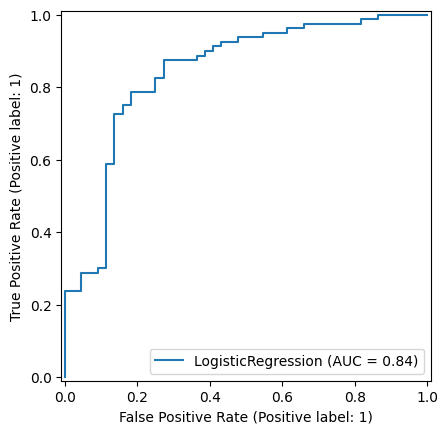

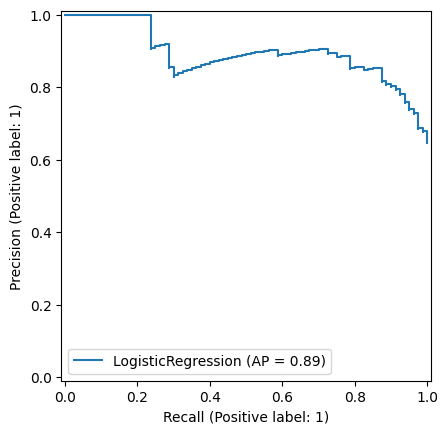

In [59]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

RocCurveDisplay.from_estimator(
    lr_clf, X_test[selected_features], y_test.values.ravel()
)


PrecisionRecallDisplay.from_estimator(
    lr_clf, X_test[selected_features], y_test.values.ravel()
)





In [60]:
from sklearn.metrics import roc_curve

y_probs = lr_clf.predict_proba(X_test[selected_features])[:, 1]

# Compute ROC curve metrics
fpr, tpr, thresholds = roc_curve( y_test.values.ravel(), y_probs)

# Create a DataFrame to store the metrics
roc_df = pd.DataFrame({
    'False Positive Rate': fpr,
    'True Positive Rate': tpr,
    'Threshold': thresholds
})


In [61]:
roc_df.to_csv(
    "roc/respiratory.tsv",
    sep="\t"
)

# Probability Prediction

In [62]:
design_matrix_test = pd.read_csv(
    "../0_data/design_matrix_test.tsv",
    sep='\t'
)

design_matrix_test['sample'] = design_matrix_test['injection']
design_matrix_test['group'] = 1

quant_matrix_predict = QuantMatrix(
    quantification_file=ms_data_test,
    design_matrix_file=design_matrix_test,
    annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
)#.impute(method="uniform_percentile", percentile=0.01)

predict_data, y_test_alll = quant_matrix_predict.to_ml(feature_column="ProteinLabel")

In [63]:
predict_data = predict_data[protein_columns].copy()

In [64]:
predict_data[protein_columns] = protein_scaler.transform(predict_data[protein_columns])

In [65]:
predict_data['resp_probability'] = lr_clf.predict_proba(predict_data[selected_features])[:, 1]

In [66]:
design_matrix_test = design_matrix_test.set_index("injection").join(
    predict_data['resp_probability']
).reset_index()

In [67]:
predict_data[['resp_probability']].to_csv(
    "predictions_test/respiratory.tsv",
    sep="\t"
)

<Axes: xlabel='resp_probability', ylabel='Count'>

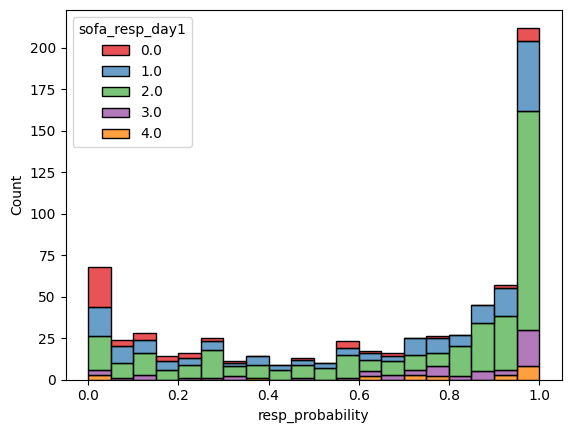

In [68]:
sns.histplot(
    data=design_matrix_test,
    x="resp_probability",
    hue="sofa_resp_day1",
    palette="Set1", 
    #kde=True,
    multiple="stack", 
    bins=20
)

In [69]:
ms_data_val = pd.read_csv(
    "../0_data/proteins_val_filtered.tsv"
    , sep="\t"
)

design_matrix_val = pd.read_csv(
    "../0_data/design_matrix_validation.tsv",
    sep='\t'
)

design_matrix_val['sample'] = design_matrix_val['injection']
design_matrix_val['group'] = 1

quant_matrix_val = QuantMatrix(
    quantification_file=ms_data_val,
    design_matrix_file=design_matrix_val,
    annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
)

val_data, y_val = quant_matrix_val.to_ml(feature_column="ProteinLabel")

In [70]:
val_data = val_data[protein_columns].copy()

In [71]:
val_data[protein_columns] = protein_scaler.transform(val_data[protein_columns])

In [72]:
val_data['resp_probability'] = lr_clf.predict_proba(val_data[selected_features])[:, 1]

In [73]:
design_matrix_val = design_matrix_val.set_index("injection").join(
    val_data['resp_probability']
).reset_index()

In [74]:
val_data[['resp_probability']].to_csv(
    "predictions_val/respiratory.tsv",
    sep="\t"
)

<Axes: xlabel='resp_probability', ylabel='Count'>

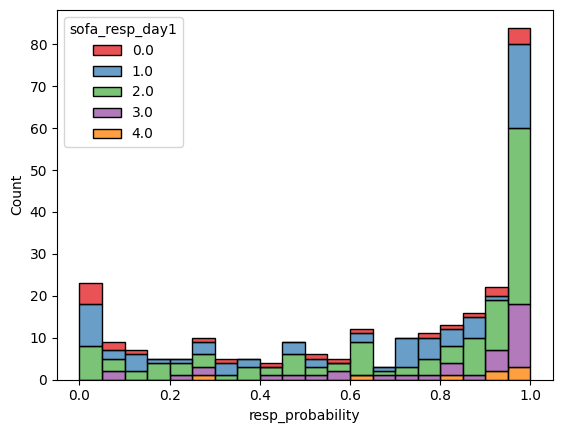

In [75]:
sns.histplot(
    data=design_matrix_val,
    x="resp_probability",
    hue="sofa_resp_day1",
    palette="Set1", 
    #kde=True,
    multiple="stack", 
    bins=20
)

In [76]:
ms_data_hero = pd.read_csv(
    "../0_data/proteins_hero_filtered.tsv"
    , sep="\t"
)

design_matrix_hero = pd.read_csv(
    "../0_data/design_matrix_hero.tsv",
    sep='\t'
)

design_matrix_hero['sample'] = design_matrix_hero['injection']
design_matrix_hero['group'] = 1

quant_matrix_hero = QuantMatrix(
    quantification_file=ms_data_hero,
    design_matrix_file=design_matrix_hero,
    annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
)

hero_data, y_hero = quant_matrix_hero.to_ml(feature_column="ProteinLabel")

In [77]:
hero_data = hero_data[protein_columns].copy()

In [78]:
hero_data[protein_columns] = protein_scaler.transform(hero_data[protein_columns])

In [79]:
hero_data['resp_probability'] = lr_clf.predict_proba(hero_data[selected_features])[:, 1]

In [80]:
design_matrix_hero = design_matrix_hero.set_index("injection").join(
    hero_data['resp_probability']
).reset_index()

In [81]:
hero_data[['resp_probability']].to_csv(
    "predictions_external/respiratory.tsv",
    sep="\t"
)

<Axes: xlabel='resp_probability', ylabel='Count'>

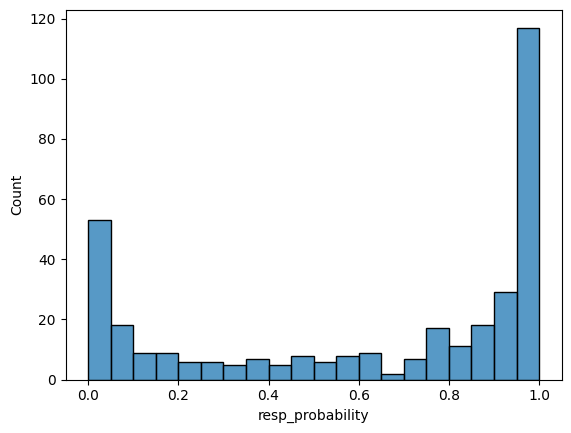

In [82]:
sns.histplot(
    data=hero_data,
    x="resp_probability",
    #hue="sofa_resp_day1",
    palette="Set1", 
    #kde=True,
    multiple="stack", 
    bins=20
)

In [83]:
from joblib import dump


with open("models/resp_protein_model.pkl", "wb") as f:

    dump(lr_clf, f)

with open("models/resp_protein_scaler.pkl", "wb") as f:

    dump(protein_scaler, f)
